# Hadley Cell Metrics

This notebook demonstrates how to use the PMP Hadley Cell API. The API uses meridional wind data and surface pressure data to calculate the meridional stream function (psi) from zonal-mean (averaged over all longitudes) meridional wind. The API can produce monthly psi, annual edge positions, and climatological psi at 500 hPa. 

##### References

- Hur, I., Yoo, C., Yeh, S.-W., Kim, Y.-H., & Seo, K.-H. (2024). Processes driving the intermodel spread of the Southern Hemisphere Hadley Circulation expansion in CMIP6 models. Journal of Geophysical Research: Atmospheres, 129, e2024JD041726. https://doi.org/10.1029/2024JD041726
- Hur, I., Kim, M., Kwak, K. et al. Hadley Circulation in the Present and Future Climate Simulations of the K-ACE Model. Asia-Pac J Atmos Sci 58, 353-363 (2022). https://doi.org/10.1007/s13143-021-00256-z


In [1]:
from pathlib import Path

import xarray as xr
import xcdat as xc
from pcmdi_metrics.hadley_cell import hadley_cell_metrics

## Example 1: Raw ERA-5 Data

Pre-process sample data:

In [2]:
model_name = 'ERA5-raw-data'
vwnd_data_path = "/global/cfs/projectdirs/m4581/obs4MIPs/obs4MIPs_input/ECMWF/ERA5/RDA/va-plev37"
psl_data_path = "/global/cfs/projectdirs/m4581/obs4MIPs/obs4MIPs_input/ECMWF/ERA5/RDA/psl"
data_output_path = "demo_output/hadley_cell_ERA5-raw"

In [ ]:
vwnd_files = sorted(Path(vwnd_data_path).glob("*.nc"))
psl_files = sorted(Path(psl_data_path).glob("*.nc"))

if not vwnd_files:
    raise FileNotFoundError(f"No .nc files found in {vwnd_data_path}")
if not psl_files:
    raise FileNotFoundError(f"No .nc files found in {psl_data_path}")

vwnd_datasets = xr.open_mfdataset(vwnd_files, combine="by_coords")
ps_datasets = xr.open_mfdataset(psl_files, combine="by_coords")

NOTE: add a regridding step for high resolution datasets to reduce computation time

In [4]:
target_grid = xc.regridder.grid.create_uniform_grid(-90, 90, 2, -180, 180, 2)
vwnd_regridded = vwnd_datasets.regridder.horizontal('V', target_grid, tool='xesmf', method='bilinear')
ps_regridded = ps_datasets.regridder.horizontal('MSL', target_grid, tool='xesmf', method='bilinear')

In [5]:
hadley_cell_metrics(
    vwnd_ds = vwnd_regridded,
    ps_ds = ps_regridded,
    vwnd_var = 'V',
    ps_var = 'MSL',
    output_dir = data_output_path,
    model_name = model_name,
    lev_dim = 'level'
)

Saved: demo_output/hadley_cell_ERA5-raw/ERA5-raw-data_monthly_psi.nc
Saved: demo_output/hadley_cell_ERA5-raw/ERA5-raw-data_annual_edges.nc
Saved: demo_output/hadley_cell_ERA5-raw/ERA5-raw-data_seasonal_psi.png
Saved: demo_output/hadley_cell_ERA5-raw/ERA5-raw-data_clim_psi500.nc


{'monthly_psi': 'demo_output/hadley_cell_ERA5-raw/ERA5-raw-data_monthly_psi.nc',
 'annual_edges': 'demo_output/hadley_cell_ERA5-raw/ERA5-raw-data_annual_edges.nc',
 'clim_psi500': 'demo_output/hadley_cell_ERA5-raw/ERA5-raw-data_clim_psi500.nc',
 'clim_plot': 'demo_output/hadley_cell_ERA5-raw/ERA5-raw-data_seasonal_psi.png'}

Display the seasonal psi image file:

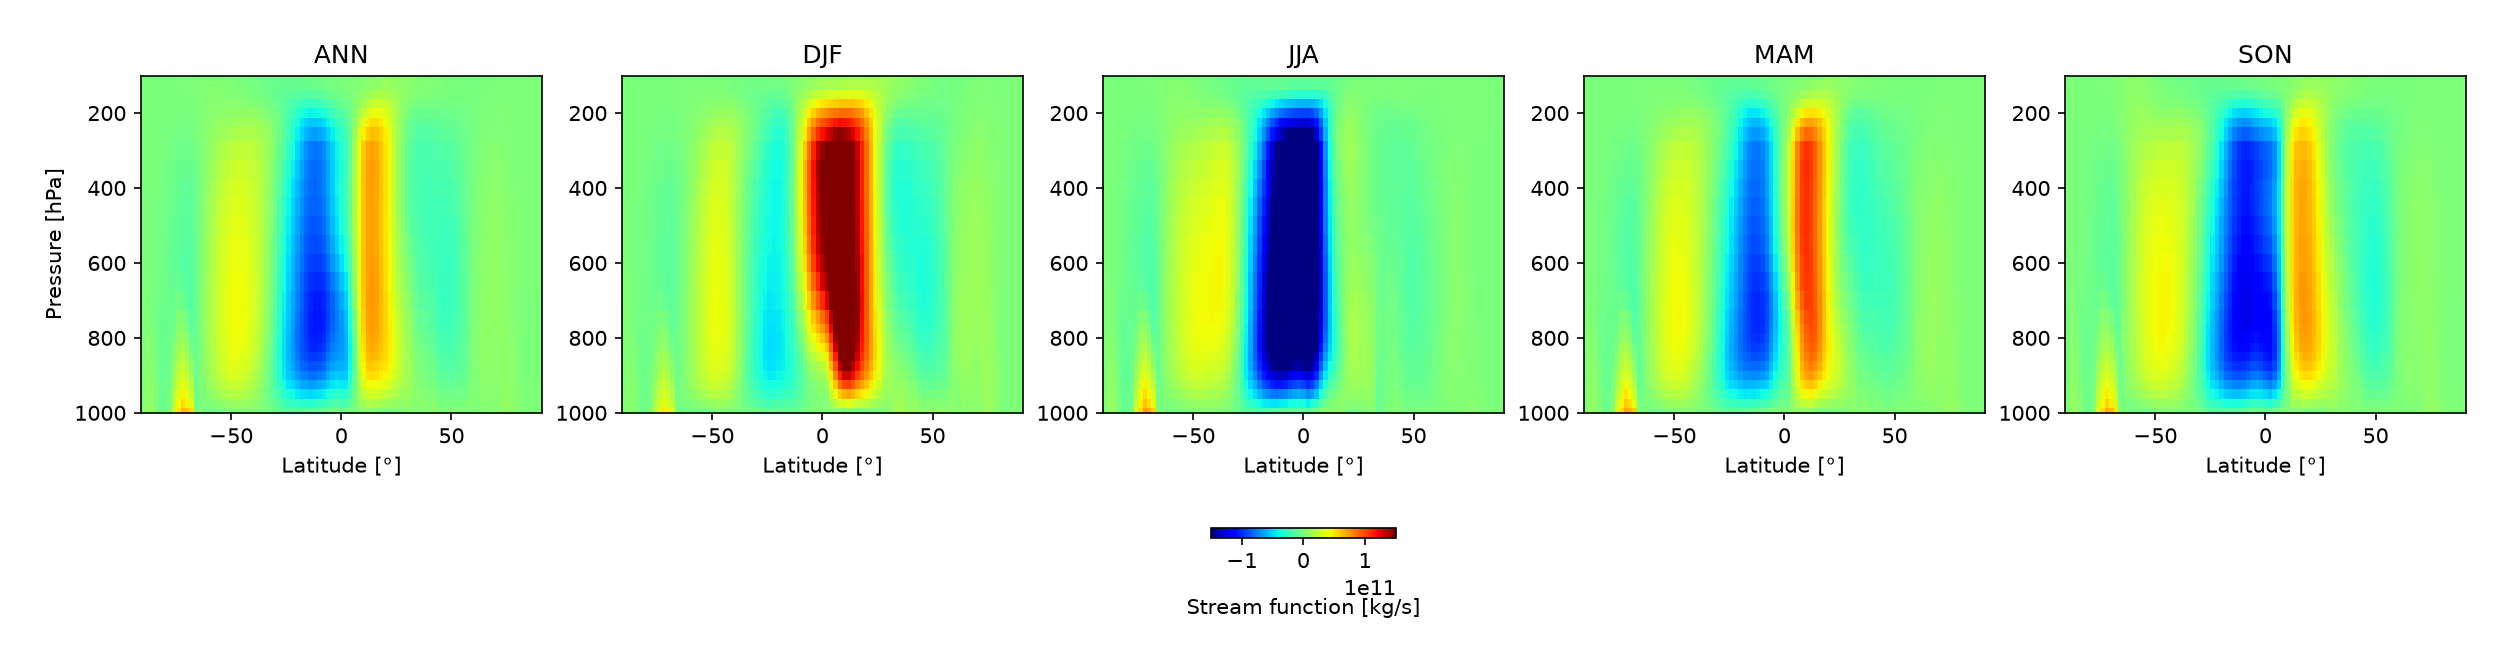

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Read the PNG image
img = mpimg.imread(f'{data_output_path}/{model_name}_seasonal_psi.png')

# Display high quality image without layout padding
height, width, _ = img.shape
fig = plt.figure(figsize=(width/300, height/300), dpi=300)

ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)

ax.imshow(img)
plt.show()

Plot the northern hemisphere and southern hemisphere edge positions over time:

In [7]:
edges = xr.open_dataset(f'{data_output_path}/{model_name}_annual_edges.nc')

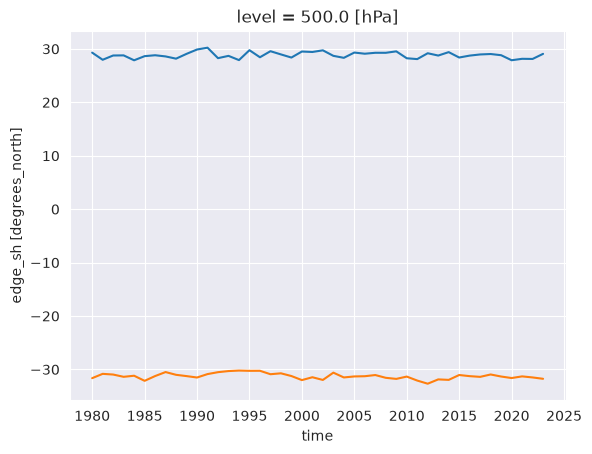

In [8]:
import seaborn as sns

sns.set_style(style="darkgrid")
edges.edge_nh.plot(x='time')
edges.edge_sh.plot(x='time')

## Example 2: Obs4MIPs data

In [9]:
model_name = 'ERA5-Obs4MIPs-data'
vwnd_data_path = "/global/cfs/projectdirs/m4581/obs4MIPs/obs4MIPs/ECMWF/ERA-5/mon/va/gn/latest"
psl_data_path = "/global/cfs/projectdirs/m4581/obs4MIPs/obs4MIPs/ECMWF/ERA-5/mon/psl/gn/latest"
data_output_path = "demo_output/hadley_cell_ERA5-obs4MIPs"

In [10]:
vwnd_files = sorted(Path(vwnd_data_path).glob("*.nc"))
psl_files = sorted(Path(psl_data_path).glob("*.nc"))

if not vwnd_files:
        raise FileNotFoundError(f"No .nc files found in {vwnd_data_path}")
if not psl_files:
    raise FileNotFoundError(f"No .nc files found in {psl_data_path}")

vwnd_datasets = xr.open_mfdataset(vwnd_files, combine="by_coords")
ps_datasets = xr.open_mfdataset(psl_files, combine="by_coords")

/tmp/ipykernel_1753043/2131145780.py:9: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  vwnd_datasets = xr.open_mfdataset(vwnd_files, combine="by_coords")
/tmp/ipykernel_1753043/2131145780.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ps_datasets = xr.open_mfdataset(psl_files, combine="by_coords")


In [11]:
target_grid = xc.regridder.grid.create_uniform_grid(-90, 90, 2, -180, 180, 2)
vwnd_regridded = vwnd_datasets.regridder.horizontal('va', target_grid, tool='xesmf', method='bilinear')
ps_regridded = ps_datasets.regridder.horizontal('psl', target_grid, tool='xesmf', method='bilinear')

In [12]:
hadley_cell_metrics(
    vwnd_ds = vwnd_regridded,
    ps_ds = ps_regridded,
    vwnd_var = 'va',
    ps_var = 'psl',
    output_dir = data_output_path,
    model_name = model_name,
    lev_dim = 'plev'
)

Saved: demo_output/hadley_cell_ERA5-obs4MIPs/ERA5-Obs4MIPs-data_monthly_psi.nc
Saved: demo_output/hadley_cell_ERA5-obs4MIPs/ERA5-Obs4MIPs-data_annual_edges.nc
Saved: demo_output/hadley_cell_ERA5-obs4MIPs/ERA5-Obs4MIPs-data_seasonal_psi.png
Saved: demo_output/hadley_cell_ERA5-obs4MIPs/ERA5-Obs4MIPs-data_clim_psi500.nc


{'monthly_psi': 'demo_output/hadley_cell_ERA5-obs4MIPs/ERA5-Obs4MIPs-data_monthly_psi.nc',
 'annual_edges': 'demo_output/hadley_cell_ERA5-obs4MIPs/ERA5-Obs4MIPs-data_annual_edges.nc',
 'clim_psi500': 'demo_output/hadley_cell_ERA5-obs4MIPs/ERA5-Obs4MIPs-data_clim_psi500.nc',
 'clim_plot': 'demo_output/hadley_cell_ERA5-obs4MIPs/ERA5-Obs4MIPs-data_seasonal_psi.png'}

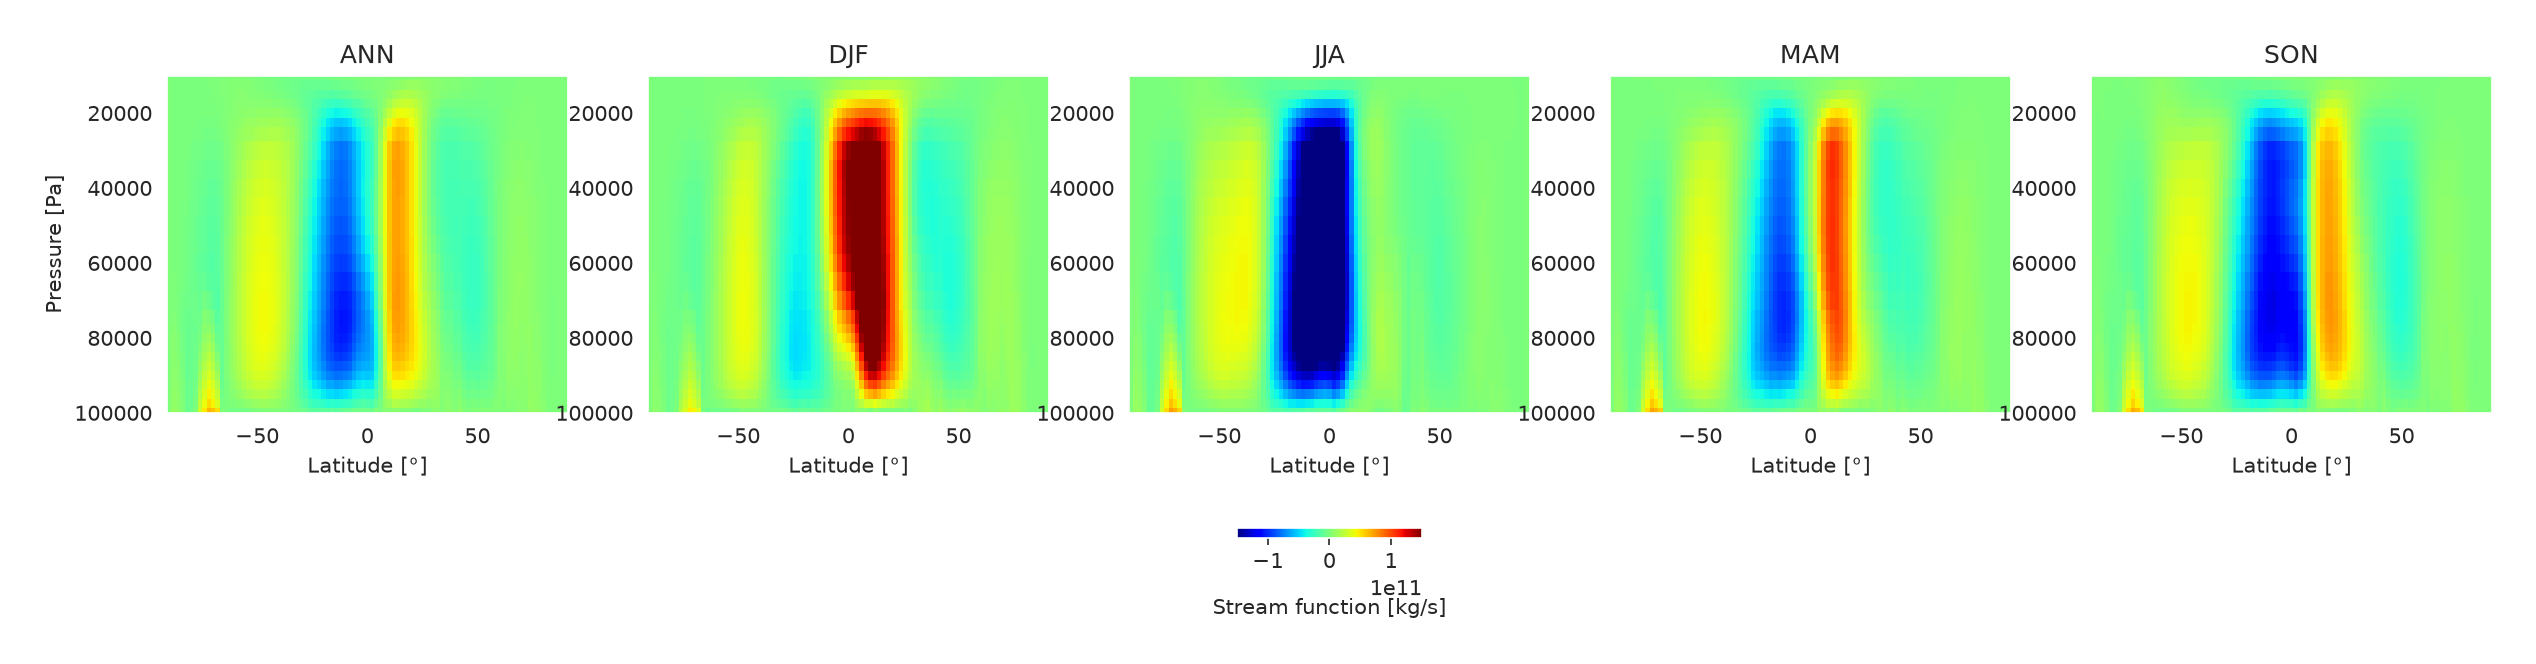

In [13]:
# Read the PNG image
img = mpimg.imread(f'{data_output_path}/{model_name}_seasonal_psi.png')

# Display high quality image without layout padding
height, width, _ = img.shape
fig = plt.figure(figsize=(width/300, height/300), dpi=300)

ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)

ax.imshow(img)
plt.show()

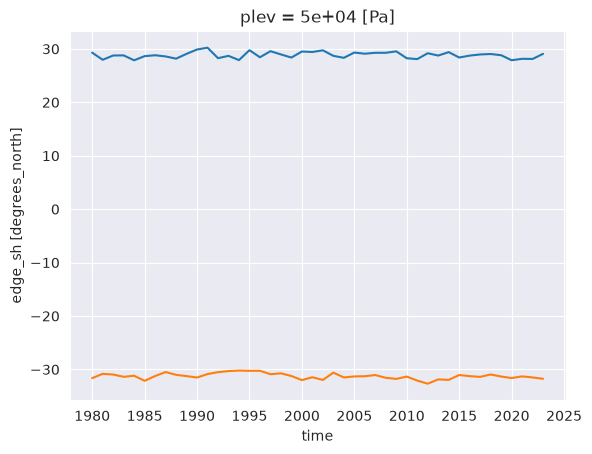

In [14]:
edges = xr.open_dataset(f'{data_output_path}/{model_name}_annual_edges.nc')

sns.set_style(style="darkgrid")
edges.edge_nh.plot(x='time')
edges.edge_sh.plot(x='time')

## Example 3: E3SM-2-1 data

In [15]:
model_name = "E3SM-2-1"
vwnd_data_path = "/global/cfs/projectdirs/m3522/datalake/CMIP6/CMIP/E3SM-Project/E3SM-2-1/historical/r1i1p1f1/Amon/va/gr/v20240207"
psl_data_path = "/global/cfs/projectdirs/m3522/datalake/CMIP6/CMIP/E3SM-Project/E3SM-2-1/historical/r1i1p1f1/Amon/psl/gr/v20240206"
data_output_path = "demo_output/E3SM-2-1"

In [16]:
vwnd_files = sorted(Path(vwnd_data_path).glob("*.nc"))
psl_files = sorted(Path(psl_data_path).glob("*.nc"))

if not vwnd_files:
        raise FileNotFoundError(f"No .nc files found in {vwnd_data_path}")
if not psl_files:
    raise FileNotFoundError(f"No .nc files found in {psl_data_path}")

vwnd_datasets = xr.open_mfdataset(vwnd_files, combine="by_coords")
ps_datasets = xr.open_mfdataset(psl_files, combine="by_coords")

/tmp/ipykernel_1753043/2131145780.py:9: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  vwnd_datasets = xr.open_mfdataset(vwnd_files, combine="by_coords")
/tmp/ipykernel_1753043/2131145780.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ps_datasets = xr.open_mfdataset(psl_files, combine="by_coords")


In [17]:
target_grid = xc.regridder.grid.create_uniform_grid(-90, 90, 2, -180, 180, 2)
vwnd_regridded = vwnd_datasets.regridder.horizontal('va', target_grid, tool='xesmf', method='bilinear')
ps_regridded = ps_datasets.regridder.horizontal('psl', target_grid, tool='xesmf', method='bilinear')

In [18]:
hadley_cell_metrics(
    vwnd_ds = vwnd_regridded,
    ps_ds = ps_regridded,
    vwnd_var = 'va',
    ps_var = 'psl',
    output_dir = data_output_path,
    model_name = model_name,
    lev_dim = 'plev'
)

Saved: demo_output/E3SM-2-1/E3SM-2-1_monthly_psi.nc
Saved: demo_output/E3SM-2-1/E3SM-2-1_annual_edges.nc
Saved: demo_output/E3SM-2-1/E3SM-2-1_seasonal_psi.png
Saved: demo_output/E3SM-2-1/E3SM-2-1_clim_psi500.nc


{'monthly_psi': 'demo_output/E3SM-2-1/E3SM-2-1_monthly_psi.nc',
 'annual_edges': 'demo_output/E3SM-2-1/E3SM-2-1_annual_edges.nc',
 'clim_psi500': 'demo_output/E3SM-2-1/E3SM-2-1_clim_psi500.nc',
 'clim_plot': 'demo_output/E3SM-2-1/E3SM-2-1_seasonal_psi.png'}

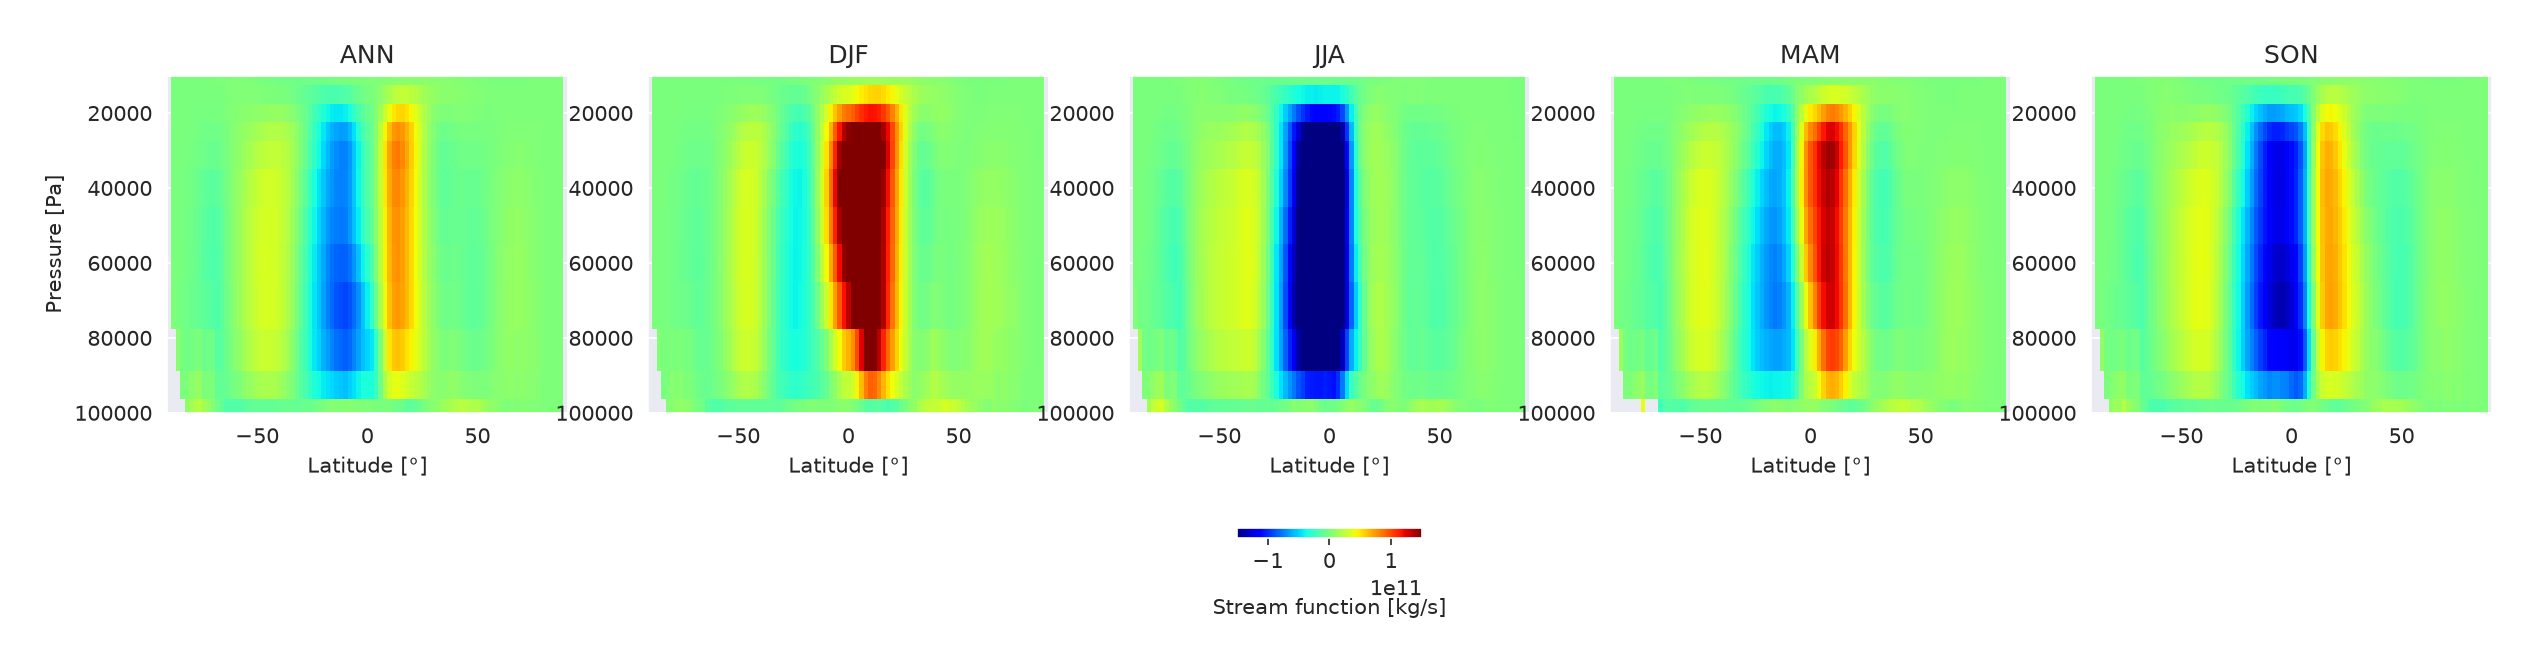

In [19]:
# Read the PNG image
img = mpimg.imread(f'{data_output_path}/{model_name}_seasonal_psi.png')

# Display high quality image without layout padding
height, width, _ = img.shape
fig = plt.figure(figsize=(width/300, height/300), dpi=300)

ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)

ax.imshow(img)
plt.show()

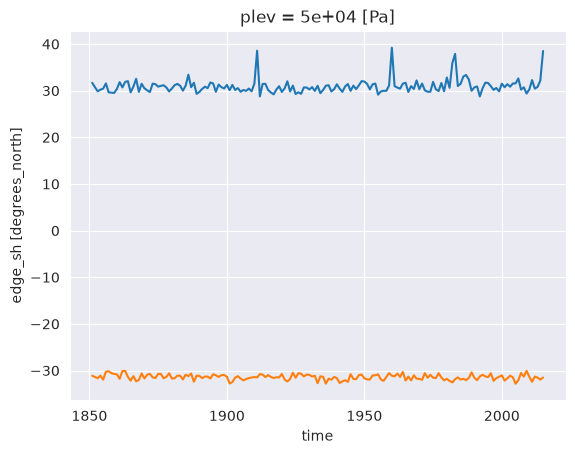

In [20]:
edges = xr.open_dataset(f'{data_output_path}/{model_name}_annual_edges.nc')

sns.set_style(style="darkgrid")
edges.edge_nh.plot(x='time')
edges.edge_sh.plot(x='time')